# ROCK-PAPER-SCISSORS: Multi-class Classification
## Comparing ALL Techniques: MLP → Augmentation → HOG → CNN → Transfer Learning

**Goal:** Maximize validation accuracy - no more constraints!

**Models Compared:**
1. Decision Tree (baseline)
2. Logistic Regression (baseline)
3. **MLP** - Feed-Forward Neural Network
4. **MLP + Data Augmentation** - More training data
5. **MLP + HOG Features** - Better features
6. **CNN** - Spatial learning
7. **Transfer Learning** - Pre-trained features

## 1. Setup and Imports

In [1]:
import sys
!{sys.executable} -m pip install -U scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 4.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.0 MB 3.8 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.0 MB 4.2 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.0 MB 3.9 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.0 MB 4.3 MB/s eta 0:00:01
   -------------------------- ------------- 5.2/8.0 MB 4.4 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 4.3 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 4.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 4.0 MB/s  0:00:02
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling

In [2]:
import sys
!{sys.executable} -m pip install -U scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.9 MB 859.2 kB/s eta 0:00:14
   --- ------------------------------------ 1.0/11.9 MB 1.3 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/11.9 MB 1.4 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/11.9 MB 1.7 MB/s eta 0:00:07
   ------- -------------------------------- 2.4/11.9 MB 1.7 MB/s eta 0:00:06
   ---------- ----------------------------- 3.1/11.9 MB 2.0 MB/s eta 0:00:05
   -------------- ------------------------- 4.2/11.9 MB 2.4 MB/s eta 0:00:04
   --------------- ------------------------ 4.7/11.9 MB 2.4 MB/s eta 0:00:03
   ------------------- -------------------- 5.8/11.9 MB 2.6 MB/s eta 0:00:03
   --------------------- 

In [38]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os

# Import from src/ modules (no more local function definitions!)
from src.data import load_images_as_numpy
from src.models import build_mlp_model, build_cnn_model, build_transfer_model
from src.features import augment_dataset, extract_hog_features, apply_standard_scaler
from src.train import compile_model, get_callbacks
from src.eval import evaluate_model, plot_history

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
Keras version: 3.13.1


In [4]:
DATA_ROOT = "../data/rps"
IMG_H, IMG_W = 224, 224
BATCH_SIZE = 16
EPOCHS = 90
CLASSES = ['paper', 'rock', 'scissor']
NUM_CLASSES = len(CLASSES)

print(f"Data root: {DATA_ROOT}")
print(f"Image size: {IMG_H}x{IMG_W}")
print(f"Classes: {CLASSES}")

Data root: ../data/rps
Image size: 224x224
Classes: ['paper', 'rock', 'scissor']


## 2. Load Data as NumPy Arrays

In [5]:
print("Loading training data...")
X_train, y_train, class_names = load_images_as_numpy(
    os.path.join(DATA_ROOT, 'train')
)

print("\nLoading validation data...")
X_val, y_val, _ = load_images_as_numpy(
    os.path.join(DATA_ROOT, 'val'),
    verbose=False
)

print("\nLoading test data...")
X_test, y_test, _ = load_images_as_numpy(
    os.path.join(DATA_ROOT, 'test'),
    verbose=False
)

print("\n" + "="*60)
print("DATA LOADED SUCCESSFULLY")
print("="*60)
print(f"Train set: {X_train.shape[0]} images, shape {X_train.shape[1:]}")
print(f"Validation set: {X_val.shape[0]} images, shape {X_val.shape[1:]}")
print(f"Test set: {X_test.shape[0]} images, shape {X_test.shape[1:]}")

print("\nClass distribution in training:")
for i, class_name in enumerate(CLASSES):
    count = np.sum(y_train == i)
    print(f"  {class_name}: {count} images ({count/len(y_train)*100:.1f}%)")

Loading training data...
Loading paper... 266 images
Loading rock... 267 images
Loading scissor... 265 images

Loading validation data...

Loading test data...

DATA LOADED SUCCESSFULLY
Train set: 798 images, shape (224, 224, 3)
Validation set: 199 images, shape (224, 224, 3)
Test set: 25 images, shape (224, 224, 3)

Class distribution in training:
  paper: 266 images (33.3%)
  rock: 267 images (33.5%)
  scissor: 265 images (33.2%)


## 3. Visualize Sample Images

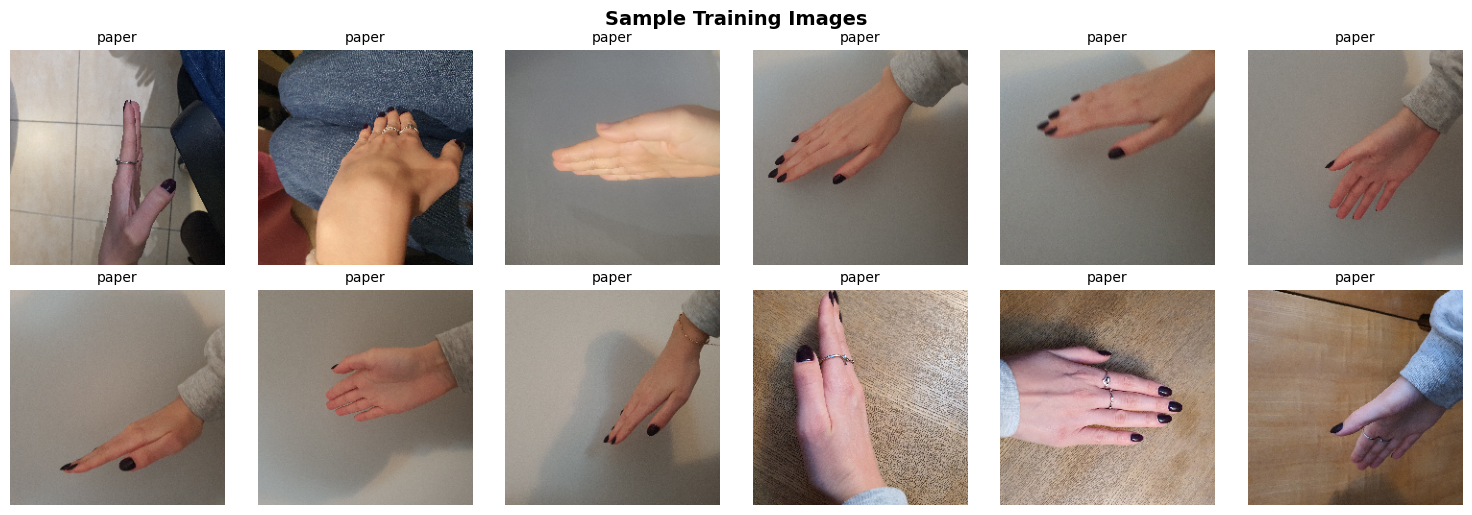

In [6]:
plt.figure(figsize=(15, 5))
for i in range(min(12, len(X_train))):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_train[i])
    plt.title(CLASSES[y_train[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Sample Training Images', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Prepare Data for MLP (Flatten)

In [7]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Original shape: {X_train.shape}")
print(f"Flattened shape: {X_train_flat.shape}")
print(f"Each image is now a vector of {X_train_flat.shape[1]:,} features")

Original shape: (798, 224, 224, 3)
Flattened shape: (798, 150528)
Each image is now a vector of 150,528 features


In [8]:
# Apply StandardScaler for better MLP performance
print("Applying StandardScaler (zero mean, unit variance)...")
X_train_scaled, X_val_scaled, X_test_scaled, scaler = apply_standard_scaler(
    X_train_flat, X_val_flat, X_test_flat
)

print(f"\nBefore scaling:")
print(f"  Mean: {X_train_flat.mean():.4f}, Std: {X_train_flat.std():.4f}")
print(f"After scaling:")
print(f"  Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print("StandardScaler improves MLP convergence by normalizing features!")

Applying StandardScaler (zero mean, unit variance)...

Before scaling:
  Mean: 0.4938, Std: 0.2346
After scaling:
  Mean: -0.0000, Std: 1.0000
StandardScaler improves MLP convergence by normalizing features!


## 5. Classical ML Baselines

In [9]:
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_model.fit(X_train_flat, y_train)
y_val_pred_dt = dt_model.predict(X_val_flat)
dt_acc = accuracy_score(y_val, y_val_pred_dt)
print(f"Decision Tree Validation Accuracy: {dt_acc:.2%}")

Training Decision Tree...
Decision Tree Validation Accuracy: 48.24%


In [10]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr_model.fit(X_train_flat, y_train)
y_val_pred_lr = lr_model.predict(X_val_flat)
lr_acc = accuracy_score(y_val, y_val_pred_lr)
print(f"Logistic Regression Validation Accuracy: {lr_acc:.2%}")

Training Logistic Regression...
Logistic Regression Validation Accuracy: 61.81%


## 6. Baseline MLP Model (with StandardScaler)

In [11]:
mlp_model = build_mlp_model(X_train_scaled.shape[1], NUM_CLASSES)
mlp_model.summary()

Model: "MLP_Optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │      77,070,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,239,043 (294.64 MB)

 Trainable params: 77,237,251 (294.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

TRAINING BASELINE MLP (with StandardScaler)
Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 485ms/step - accuracy: 0.3459 - loss: 1.2867 - val_accuracy: 0.4171 - val_loss: 1.5844 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 460ms/step - accuracy: 0.4549 - loss: 1.1188 - val_accuracy: 0.3970 - val_loss: 1.2312 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 501ms/step - accuracy: 0.4774 - loss: 1.0501 - val_accuracy: 0.3970 - val_loss: 1.2231 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 507ms/step - accuracy: 0.5238 - loss: 0.9833 - val_accuracy: 0.4221 - val_loss: 1.2375 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 483ms/step - accuracy: 0.5952 - loss: 0.8835 - val_accuracy: 0.4573 - val_loss: 1.1425 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 477ms/step - accuracy: 0.6203 - loss: 0.8550 - val_accuracy: 0.4523 - val_loss: 1.2034 - learning_rate: 0.0010
Epoch 7/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 

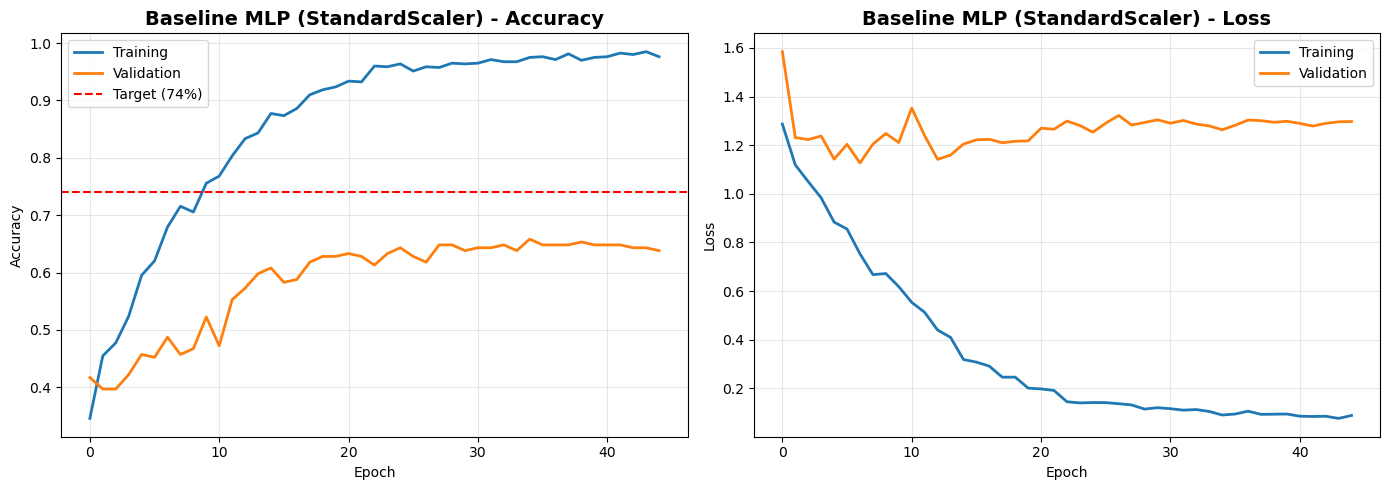

Best val accuracy: 65.83% at epoch 35


In [12]:
compile_model(mlp_model)
callbacks = get_callbacks()

print("="*70)
print("TRAINING BASELINE MLP (with StandardScaler)")
print("="*70)

history_mlp = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

mlp_val_loss, mlp_val_acc = mlp_model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"\nBaseline MLP Validation Accuracy: {mlp_val_acc:.2%}")
plot_history(history_mlp, title="Baseline MLP (StandardScaler)")

## 7. MLP + Data Augmentation (with StandardScaler)

In [13]:
print("Augmenting training data...")
X_train_aug, y_train_aug = augment_dataset(X_train, y_train, augment_factor=2)
print(f"Original training size: {len(X_train)}")
print(f"Augmented training size: {len(X_train_aug)}")

X_train_aug_flat = X_train_aug.reshape(X_train_aug.shape[0], -1)

# Apply StandardScaler to augmented data
print("\nApplying StandardScaler to augmented data...")
X_train_aug_scaled, X_val_aug_scaled, X_test_aug_scaled, scaler_aug = apply_standard_scaler(
    X_train_aug_flat, X_val_flat, X_test_flat
)

Augmenting training data...
Original training size: 798
Augmented training size: 2394

Applying StandardScaler to augmented data...


TRAINING MLP + DATA AUGMENTATION (with StandardScaler)
Epoch 1/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 496ms/step - accuracy: 0.3605 - loss: 1.2696 - val_accuracy: 0.2965 - val_loss: 1.1128 - learning_rate: 0.0010
Epoch 2/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 481ms/step - accuracy: 0.3454 - loss: 1.1831 - val_accuracy: 0.3568 - val_loss: 1.1046 - learning_rate: 0.0010
Epoch 3/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 478ms/step - accuracy: 0.3588 - loss: 1.1616 - val_accuracy: 0.3367 - val_loss: 1.1000 - learning_rate: 0.0010
Epoch 4/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 75s 500ms/step - accuracy: 0.3571 - loss: 1.1434 - val_accuracy: 0.3467 - val_loss: 1.0970 - learning_rate: 0.0010
Epoch 5/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 75s 500ms/step - accuracy: 0.3588 - loss: 1.1440 - val_accuracy: 0.3869 - val_loss: 1.0885 - learning_rate: 0.0010
Epoch 6/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 75s 500ms/step - accuracy: 0.3596 - loss: 1.1352 - val_accuracy: 0.3869 - val_loss: 1.1033 - learning_rate: 0.0010
Epoch 7/90
150/

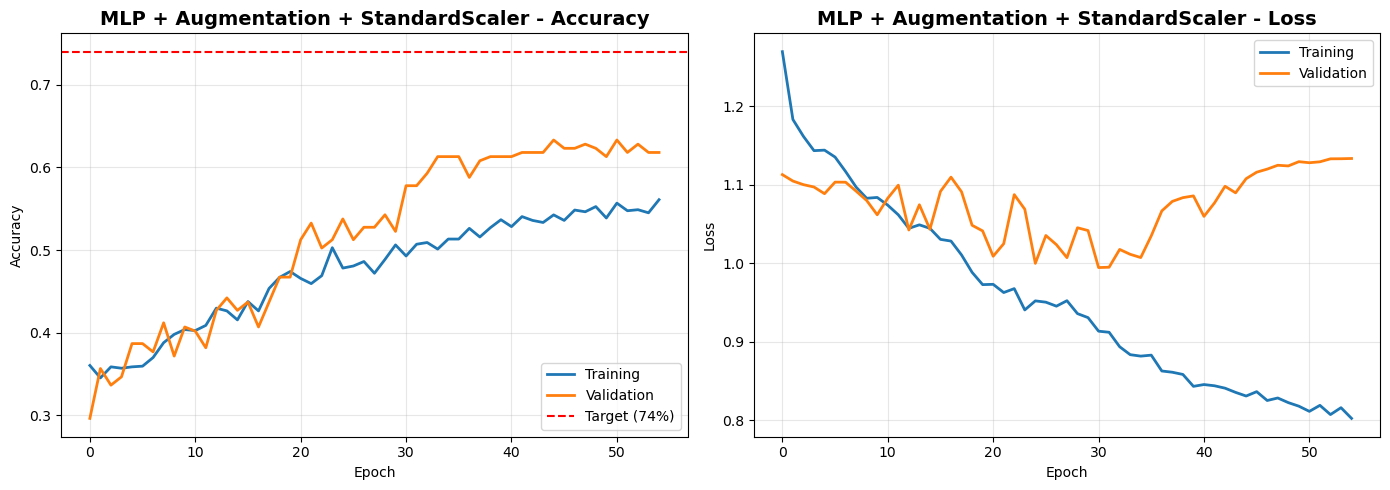

Best val accuracy: 63.32% at epoch 45


In [14]:
mlp_aug_model = build_mlp_model(X_train_aug_scaled.shape[1], NUM_CLASSES)
compile_model(mlp_aug_model)
callbacks_aug = get_callbacks()

print("="*70)
print("TRAINING MLP + DATA AUGMENTATION (with StandardScaler)")
print("="*70)

history_mlp_aug = mlp_aug_model.fit(
    X_train_aug_scaled, y_train_aug,
    validation_data=(X_val_aug_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_aug,
    verbose=1
)

_, mlp_aug_val_acc = mlp_aug_model.evaluate(X_val_aug_scaled, y_val, verbose=0)
print(f"\nMLP + Augmentation Validation Accuracy: {mlp_aug_val_acc:.2%}")
plot_history(history_mlp_aug, title="MLP + Augmentation + StandardScaler")

## 8. MLP + HOG Features (with StandardScaler)

In [15]:
print("Extracting HOG features...")
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)

print(f"Original features: {X_train_flat.shape[1]:,}")
print(f"HOG features: {X_train_hog.shape[1]:,}")

# Apply StandardScaler to HOG features
print("\nApplying StandardScaler to HOG features...")
X_train_hog_scaled, X_val_hog_scaled, X_test_hog_scaled, scaler_hog = apply_standard_scaler(
    X_train_hog, X_val_hog, X_test_hog
)

Extracting HOG features...
Original features: 150,528
HOG features: 6,084

Applying StandardScaler to HOG features...


TRAINING MLP + HOG FEATURES (with StandardScaler)
Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.5414 - loss: 0.9798 - val_accuracy: 0.6533 - val_loss: 0.9263 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7669 - loss: 0.5480 - val_accuracy: 0.7085 - val_loss: 0.7557 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8822 - loss: 0.3316 - val_accuracy: 0.7236 - val_loss: 0.7356 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9173 - loss: 0.2193 - val_accuracy: 0.7136 - val_loss: 0.8317 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9699 - loss: 0.1184 - val_accuracy: 0.7236 - val_loss: 0.7717 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9699 - loss: 0.0924 - val_accuracy: 0.7487 - val_loss: 0.7906 - learning_rate: 0.0010
Epoch 7/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50

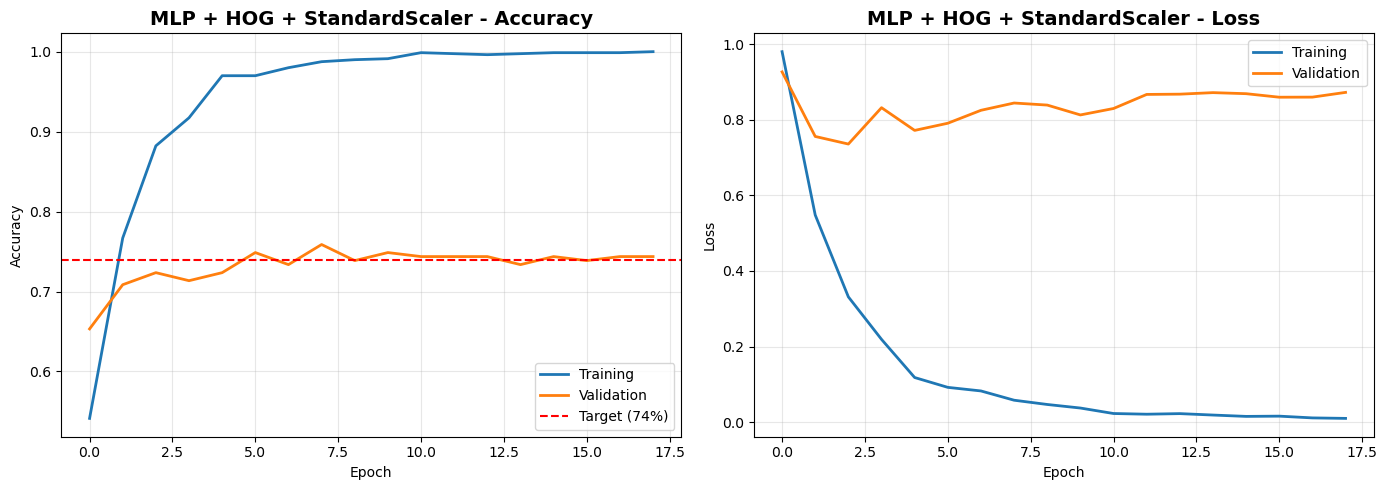

Best val accuracy: 75.88% at epoch 8


In [16]:
mlp_hog_model = build_mlp_model(X_train_hog_scaled.shape[1], NUM_CLASSES)
compile_model(mlp_hog_model)
callbacks_hog = get_callbacks()

print("="*70)
print("TRAINING MLP + HOG FEATURES (with StandardScaler)")
print("="*70)

history_mlp_hog = mlp_hog_model.fit(
    X_train_hog_scaled, y_train,
    validation_data=(X_val_hog_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_hog,
    verbose=1
)

_, mlp_hog_val_acc = mlp_hog_model.evaluate(X_val_hog_scaled, y_val, verbose=0)
print(f"\nMLP + HOG Validation Accuracy: {mlp_hog_val_acc:.2%}")
plot_history(history_mlp_hog, title="MLP + HOG + StandardScaler")

## 9. CNN Model

In [17]:
cnn_model = build_cnn_model((IMG_H, IMG_W, 3), NUM_CLASSES)
cnn_model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │              

 Total params: 457,923 (1.75 MB)

 Trainable params: 456,451 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

TRAINING CNN
Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.3471 - loss: 1.3828 - val_accuracy: 0.3266 - val_loss: 1.4132 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.4035 - loss: 1.2476 - val_accuracy: 0.3266 - val_loss: 1.5534 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.3960 - loss: 1.2670 - val_accuracy: 0.3266 - val_loss: 1.3775 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.4599 - loss: 1.1685 - val_accuracy: 0.3216 - val_loss: 1.5581 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.4887 - loss: 1.0627 - val_accuracy: 0.3417 - val_loss: 1.3060 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.4950 - loss: 1.1070 - val_accuracy: 0.3367 - val_loss: 1.7849 - learning_rate: 0.0010
Epoch 7/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.5000 - loss: 1.0673 -

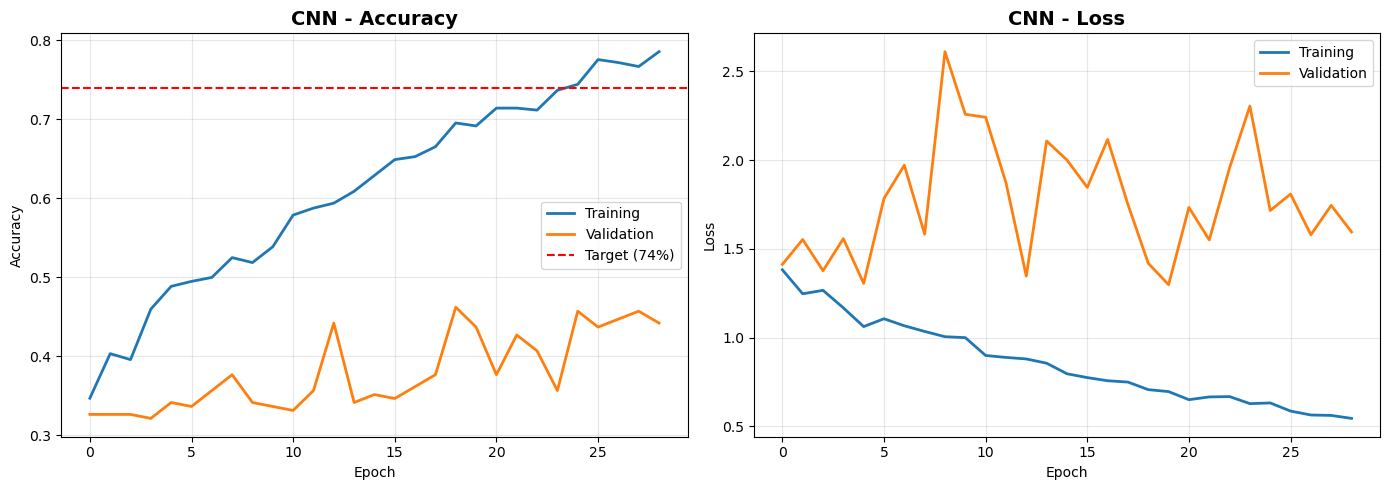

Best val accuracy: 46.23% at epoch 19


In [18]:
compile_model(cnn_model)
callbacks_cnn = get_callbacks()

print("="*70)
print("TRAINING CNN")
print("="*70)

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    verbose=1
)

_, cnn_val_acc = cnn_model.evaluate(X_val, y_val, verbose=0)
print(f"\nCNN Validation Accuracy: {cnn_val_acc:.2%}")
plot_history(history_cnn, title="CNN")

## 10. Transfer Learning (MobileNetV2)

In [19]:
transfer_model = build_transfer_model(NUM_CLASSES, input_shape=(IMG_H, IMG_W, 3))
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "TransferLearning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ multiply (Multiply)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_14 (Activation)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,587,715 (9.87 MB)

 Trainable params: 329,219 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

TRAINING TRANSFER LEARNING (MobileNetV2)
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 263ms/step - accuracy: 0.4348 - loss: 1.3145 - val_accuracy: 0.4874 - val_loss: 0.9397 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 233ms/step - accuracy: 0.6692 - loss: 0.7233 - val_accuracy: 0.6834 - val_loss: 0.6626 - learning_rate: 1.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 247ms/step - accuracy: 0.7682 - loss: 0.5805 - val_accuracy: 0.7688 - val_loss: 0.5262 - learning_rate: 1.0000e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 247ms/step - accuracy: 0.8409 - loss: 0.4136 - val_accuracy: 0.8141 - val_loss: 0.4515 - learning_rate: 1.0000e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - accuracy: 0.8609 - loss: 0.3479 - val_accuracy: 0.8543 - val_loss: 0.4024 - learning_rate: 1.0000e-04
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.8922 - loss: 0.2883 - val_accuracy: 0.8442 - val_loss: 0.3754 - learning_rate: 1.0000e-04
Epoch 7/50
50/50 

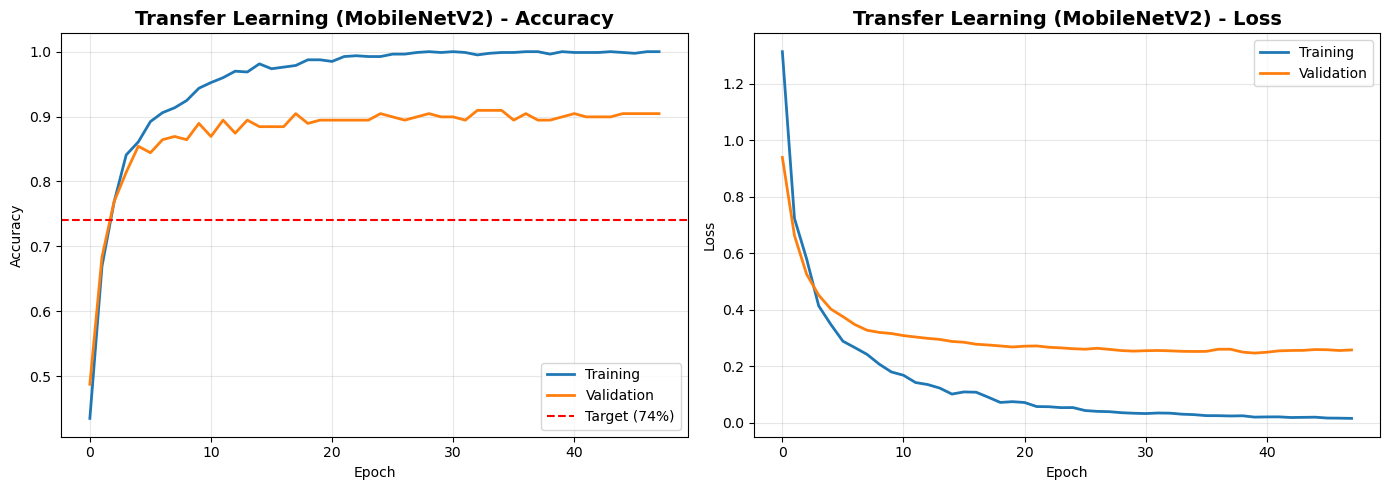

Best val accuracy: 90.95% at epoch 33


In [20]:
compile_model(transfer_model, learning_rate=0.0001)
callbacks_transfer = get_callbacks(patience=15)

print("="*70)
print("TRAINING TRANSFER LEARNING (MobileNetV2)")
print("="*70)

history_transfer = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_transfer,
    verbose=1
)

_, transfer_val_acc = transfer_model.evaluate(X_val, y_val, verbose=0)
print(f"\nTransfer Learning Validation Accuracy: {transfer_val_acc:.2%}")
plot_history(history_transfer, title="Transfer Learning (MobileNetV2)")

## 11. Final Comparison


FINAL MODEL COMPARISON
              Model  Validation Accuracy (%)  Val F1 Macro (%)  Test F1 Macro (%)
  Transfer Learning                90.954775         90.848982          95.816993
          MLP + HOG                75.879395         75.888499          84.259259
     MLP (Baseline)                65.829146         65.840375          91.904762
 MLP + Augmentation                63.316584         63.352811          83.796296
Logistic Regression                61.809045         53.230573          91.904762
      Decision Tree                48.241206         42.279102          41.835749
                CNN                46.231157         40.236447          45.698006


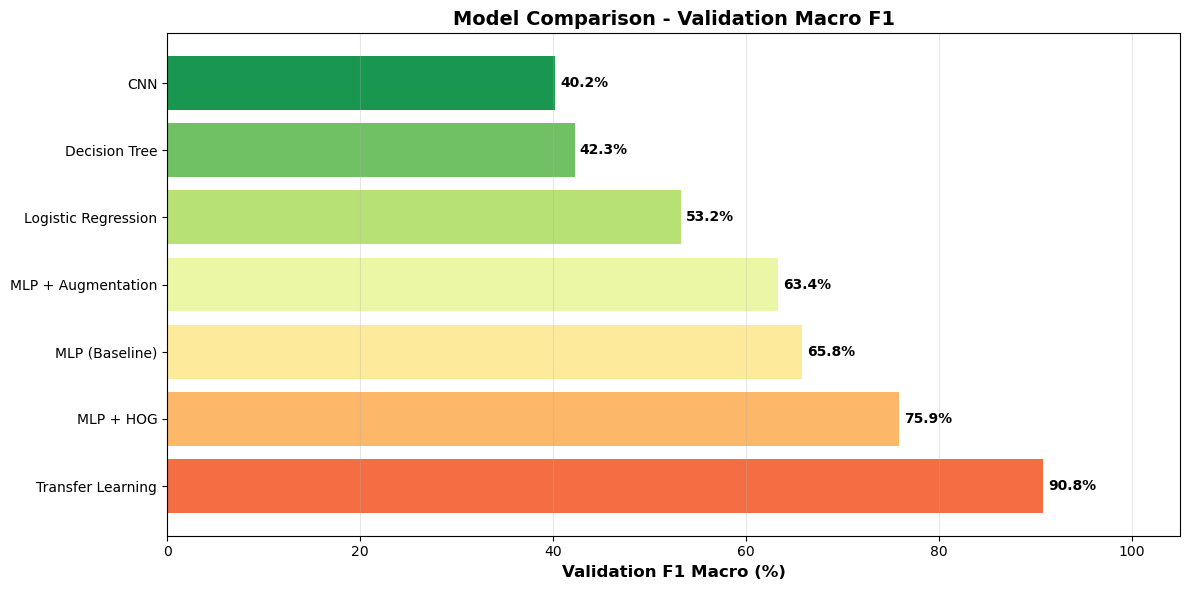

,Model,Validation Accuracy (%),Val F1 Macro (%),Test F1 Macro (%)
0,Transfer Learning,90.954775,90.848982,95.816993
1,MLP + HOG,75.879395,75.888499,84.259259
2,MLP (Baseline),65.829146,65.840375,91.904762
3,MLP + Augmentation,63.316584,63.352811,83.796296
4,Logistic Regression,61.809045,53.230573,91.904762
5,Decision Tree,48.241206,42.279102,41.835749
6,CNN,46.231157,40.236447,45.698006


In [83]:
# =========================
# FINAL MODEL COMPARISON
# =========================

# Adjust if your label order/names differ
class_names = ["rock", "paper", "scissors"]

rows = []

def add_row(name, model, Xv, yv, Xt, yt, val_acc):
    # Silence reports/plots so the cell doesn't spam output
    s = evaluate_model(
        model,
        Xv, yv,
        Xt, yt,
        class_names,
        show_plots=False,
        print_reports=False
    )
    rows.append({
        "Model": name,
        "Validation Accuracy (%)": val_acc * 100,
        "Val F1 Macro (%)": s["val"]["f1_macro"] * 100,
        "Test F1 Macro (%)": s["test"]["f1_macro"] * 100,
    })

add_row("Decision Tree", dt_model, X_val_scaled, y_val, X_test_scaled, y_test, dt_acc)
add_row("Logistic Regression", lr_model, X_val_scaled, y_val, X_test_scaled, y_test, lr_acc)
add_row("MLP (Baseline)", mlp_model, X_val_scaled, y_val, X_test_scaled, y_test, mlp_val_acc)
add_row("MLP + Augmentation", mlp_aug_model, X_val_aug_scaled, y_val, X_test_aug_scaled, y_test, mlp_aug_val_acc)
add_row("MLP + HOG", mlp_hog_model, X_val_hog_scaled, y_val, X_test_hog_scaled, y_test, mlp_hog_val_acc)
add_row("CNN", cnn_model, X_val, y_val, X_test, y_test, cnn_val_acc)
add_row("Transfer Learning", transfer_model, X_val, y_val, X_test, y_test, transfer_val_acc)

# Build + sort
results = pd.DataFrame(rows).sort_values(
    "Val F1 Macro (%)", ascending=False, na_position="last"
).reset_index(drop=True)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(results.to_string(index=False))
print("="*70)

# Plot Val F1 Macro (%)
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(results)))
bars = ax.barh(results["Model"], results["Val F1 Macro (%)"], color=colors)

ax.set_xlabel("Validation F1 Macro (%)", fontsize=12, fontweight="bold")
ax.set_title("Model Comparison - Validation Macro F1", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, 105)

for bar, val in zip(bars, results["Val F1 Macro (%)"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{val:.1f}%",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

results


## 12. Evaluate Best Model

Best model: Transfer Learning

VALIDATION RESULTS
Validation Accuracy: 90.95%
Validation F1 Macro: 90.85%

Classification report (per-class F1 is the key column):
              precision    recall  f1-score   support

       paper       0.93      0.84      0.88        67
        rock       0.92      0.99      0.95        67
     scissor       0.88      0.91      0.89        65

    accuracy                           0.91       199
   macro avg       0.91      0.91      0.91       199
weighted avg       0.91      0.91      0.91       199

Per-class F1 (VAL):
  - paper: 0.8819
  - rock: 0.9496
  - scissor: 0.8939

TEST RESULTS
Test Accuracy: 96.00%
Test F1 Macro: 95.82%

Classification report (per-class F1 is the key column):
              precision    recall  f1-score   support

       paper       1.00      0.88      0.93         8
        rock       0.89      1.00      0.94         8
     scissor       1.00      1.00      1.00         9

    accuracy                           0.96     

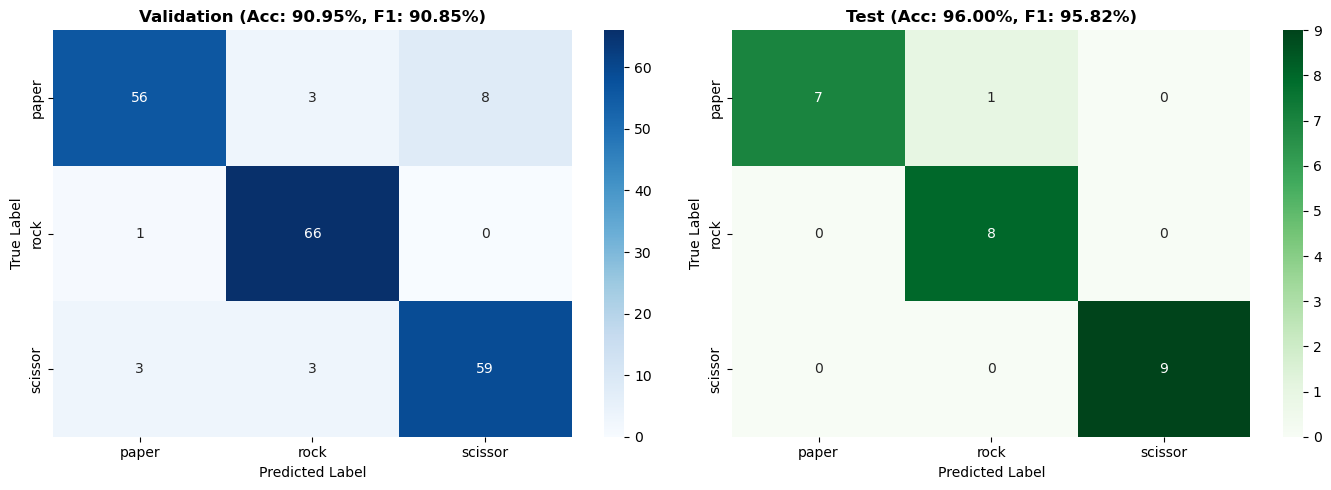


Best model metrics:
  Val F1 Macro (%):  90.85
  Test F1 Macro (%): 95.82


In [82]:
# 1️⃣ Sort results FIRST by validation macro F1
results = results.sort_values(
    "Val F1 Macro (%)",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

# Select best model AFTER sorting
best_model_name = results.iloc[0]["Model"]
print(f"Best model: {best_model_name}")

# Map model name to model object and correct inputs
if best_model_name == "Transfer Learning":
    best_model = transfer_model
    X_val_input, X_test_input = X_val, X_test

elif best_model_name == "CNN":
    best_model = cnn_model
    X_val_input, X_test_input = X_val, X_test

elif best_model_name == "MLP + HOG":
    best_model = mlp_hog_model
    X_val_input, X_test_input = X_val_hog_scaled, X_test_hog_scaled

elif best_model_name == "MLP + Augmentation":
    best_model = mlp_aug_model
    X_val_input, X_test_input = X_val_aug_scaled, X_test_aug_scaled

else:  # MLP (Baseline)
    best_model = mlp_model
    X_val_input, X_test_input = X_val_scaled, X_test_scaled

# Evaluate best model (confusion matrices + per-class F1)
best_scores = evaluate_model(
    best_model,
    X_val_input, y_val,
    X_test_input, y_test,
    CLASSES
)

# Explicit macro F1 print (clear for graders)
print("\nBest model metrics:")
print(f"  Val F1 Macro (%):  {best_scores['val']['f1_macro'] * 100:.2f}")
print(f"  Test F1 Macro (%): {best_scores['test']['f1_macro'] * 100:.2f}")


## 13. Save Best Model

In [23]:
best_model.save('rps_best_model.keras')
print(f"Best model ({best_model_name}) saved as: rps_best_model.keras")

Best model (Transfer Learning) saved as: rps_best_model.keras
